### $\varepsilon$-Greedy Policy:
$$
\begin{array}{l}
\pi(a|s) =
\left\{
\begin{array}{ll}
1 - \varepsilon + \varepsilon / m,& \text{ если } a \in \mathrm{argmax}_{a' \in \mathcal{A}}\, Q(s,a'),\\
\varepsilon / m,& \text{ иначе }
\end{array}
\right.
\end{array}
$$

In [1]:
import numpy as np

def get_epsilon_greedy_action(q_values, epsilon, action_n):
    prob = np.ones(action_n) * epsilon / action_n
    argmax_action = np.argmax(q_values)
    prob[argmax_action] += 1 - epsilon
    action = np.random.choice(np.arange(action_n), p=prob)
    return action

# SARSA

Let $Q(s,a) = 0$, $K > 0$, and $\varepsilon = 1$.

For each $k$, do

&nbsp;&nbsp;&nbsp;&nbsp; During trajectory

- From the state $S_t$, acting $A_t \sim \pi(\cdot|S_t)$,
where $\pi = \varepsilon\text{-greedy}(Q)$, get $R_t$, go to the next state $S_{t+1}$, and act $A_{t+1} \sim \pi(\cdot|S_{t+1})$

- According to $(S_t,A_t,R_t,S_{t+1},A_{t+1})$, update $Q$:
$$
Q(S_t,A_t) \leftarrow Q(S_t,A_t) + \alpha_k(R_t + \gamma Q(S_{t+1},A_{t+1}) - Q(S_t,A_t))
$$

- Set $\varepsilon = 1/k$

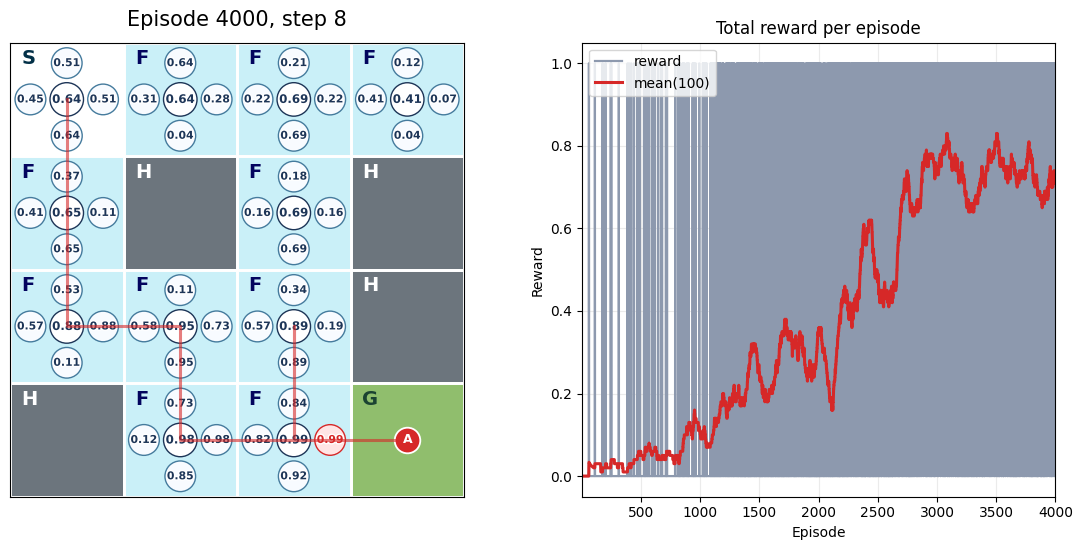

Visualized episodes: every 100th episode up to 4000
Average reward over the last 50 episodes: 0.7


In [3]:
from pathlib import Path
import importlib.util
import sys

lecture_3_dir = Path.cwd()
if lecture_3_dir.name != "Lecture_3":
    lecture_3_dir = lecture_3_dir / "Lecture_3"

env_module_path = lecture_3_dir / "env_frozen_lake.py"
env_spec = importlib.util.spec_from_file_location("lecture_3_env_frozen_lake", env_module_path)
env_module = importlib.util.module_from_spec(env_spec)
sys.modules[env_spec.name] = env_module
env_spec.loader.exec_module(env_module)
FrozenLakeEnv = env_module.FrozenLakeEnv

env = FrozenLakeEnv(map_name="4x4", slip_chance=0.2, seed=42)
grid_states = [(row, col) for row in range(env.desc.shape[0]) for col in range(env.desc.shape[1])]
actions = list(env.get_possible_actions(env.reset()))
action_n = len(actions)

q_values = {
    state: {action: 0.0 for action in actions}
    for state in grid_states
}

def get_action(state, epsilon):
    action_idx = get_epsilon_greedy_action(
        np.array([q_values[state][action] for action in actions]),
        epsilon,
        action_n,
    )
    return actions[action_idx]

episode_n = 4000
trajectory_len = 100
gamma = 0.99
alpha = 0.1
visualize_every = 100

total_rewards = []
env.configure_training_visualization(q_values, total_rewards, episode_n, visualize_every=visualize_every, delay=0.01)
try:
    for episode in range(episode_n):
        epsilon = max(0.01, 1 - episode / (episode_n - 1000))
        total_reward = 0.0

        state = env.reset()
        env.start_episode(episode + 1)
        action = get_action(state, epsilon)

        for step in range(trajectory_len):
            next_state, reward, done, _ = env.step(action)

            target = reward
            if not done:
                next_action = get_action(next_state, epsilon)
                target += gamma * q_values[next_state][next_action]

            q_values[state][action] += alpha * (target - q_values[state][action])
            total_reward += reward
            env.render()

            if done:
                break

            state = next_state
            action = next_action

        total_rewards.append(total_reward)
except KeyboardInterrupt:
    print("Stopped by user.")
print("Visualized episodes:", f"every {visualize_every}th episode up to {episode_n}")
if len(total_rewards) > 0:
    print("Average reward over the last 50 episodes:", np.mean(total_rewards[-50:]))
else:
    print("Average reward over the last 50 episodes: no completed episodes yet")
